# Tutorial 04: Run the Training and Test Phases of the WGAST Model

In this tutorial, we will run the **WGAST** model on the structured dataset we prepared earlier. This includes:

- Setting up all necessary parameters and model configurations.
- Launching the training process.
- Evaluating the trained model.

📌 This tutorial is fully customizable. The default parameters match the settings used in our paper, feel free to adjust them based on your data or hardware capabilities.


In [8]:
# === Imports ===
from pathlib import Path
import torch
import torch.backends.cudnn as cudnn
import time

import sys
import os
# Add the project root to sys.path to allow imports from other folders (e.g., 'runner', 'data_loader', etc.)
sys.path.append(os.path.abspath('..'))  # Assumes this notebook is in /tutorials/

from runner.experiment import Experiment  # Main class to manage training and testing


## Step 01 : Define and Initialize Model Parameters (from the Paper)

In [9]:
# === Configuration Class ===
class Options:
    """
    Stores all hyperparameters and paths used during training/testing.

    ⚠️ NOTE: The folder './data/Tdivision' must be generated by the previous tutorials:
        - 01_data_download.ipynb
        - 02_data_preparation.ipynb
        - 03_data_structuring.ipynb

    📌 These hyperparameters correspond to the settings used in the paper.
       Feel free to adjust them for your own experiments.
    """
    def __init__(self):
        # Training settings
        self.lr = 2e-4                  # Learning rate
        self.batch_size = 32           # Batch size
        self.epochs = 110              # Number of training epochs

        # Hardware settings
        self.cuda = True               # Enable CUDA if available
        self.ngpu = 1                  # Number of GPUs to use
        self.num_workers = 8           # Number of data loading workers

        # Data paths
        self.save_dir = Path('./data/Tdivision')      # Where to save outputs
        self.data_dir = Path('./data/Tdivision')      # Base data directory
        self.train_dir = Path('./data/Tdivision/train')  # Training data path
        self.test_dir = Path('./data/Tdivision/test')    # Testing data path

        # Image and patch parameters
        self.image_size = [400, 400]   # Size of input images
        self.patch_size = [32, 32]     # Size of image patches
        self.patch_stride = 8          # Stride for patch extraction
        self.test_patch = 32           # Patch size during testing

        # Model options
        self.ifAdaIN = True            # Use AdaIN for feature normalization
        self.ifAttention = True        # Use attention mechanism
        self.ifTwoInput = False        # Use two input streams (if applicable)
        
        # Loss weights (used in final objective function)
        self.a = 1e-2
        self.b = 1
        self.c = 1
        self.d = 1

# === Set Options ===
opt = Options()

# === Set random seed for reproducibility ===
torch.manual_seed(2024)
opt.cuda = True  # Enable CUDA if available
if not torch.cuda.is_available():
    opt.cuda = False

if opt.cuda:
    torch.cuda.manual_seed_all(2024)
    cudnn.benchmark = True       # Enable benchmark mode for optimal performance
    cudnn.deterministic = True   # Make training deterministic (reproducible)

# === Run Experiment ===
# This initializes the training/testing workflow
experiment = Experiment(opt)


Model initialization
There are 7884208 trainable parameters for generator.
There are 2765505 trainable parameters for nlayerdiscriminator.


## Step 02 : Train the Model

In [3]:
if opt.epochs > 0:
    start_time = time.time()  # Start measuring training time
    
    # Begin training process using parameters defined earlier
    # - opt.train_dir: Path to the training dataset (prepared in previous tutorials)
    # - patch_size / patch_stride: How images are split into training patches
    # - batch_size: Number of samples per training batch
    # - num_workers: Number of subprocesses used for data loading
    # - epochs: Number of full passes over the dataset
    predictions = experiment.train(opt.train_dir,
                                   opt.patch_size, 
                                   opt.patch_stride, 
                                   opt.batch_size,
                                   num_workers=1, 
                                   epochs=opt.epochs)

    end_time = time.time()  # Stop measuring training time
    
    elapsed_time = end_time - start_time
    print(f"Training took {elapsed_time:.2f} seconds")  # Display training duration


Loading data...
There are 2209 samples for training.
Training...
Learning rate for Generator: 0.0002
Learning rate for Discriminator: 0.0002
Epoch[0] - 2026-05-08 18:45:38.967085


/Users/ihsanbolum/WGAST_w--Prediction/runner/experiment.py:234: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.g_scheduler.step()
/Users/ihsanbolum/WGAST_w--Prediction/runner/experiment.py:235: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  self.pd_scheduler.step()
Processing: 100%|██████████| 69/69 [16:

Epoch[0] - 2026-05-08 19:02:02.050951


Learning rate for Generator: 0.0002
Learning rate for Discriminator: 0.0002
Epoch[1] - 2026-05-08 19:02:02.399323


Processing: 100%|██████████| 69/69 [16:21<00:00, 14.23s/it]

...

Epoch[108] - 2026-05-09 15:50:45.380494


Learning rate for Generator: 0.0002
Learning rate for Discriminator: 0.0002
Epoch[109] - 2026-05-09 15:50:45.683636


Processing: 100%|██████████| 69/69 [14:32<00:00, 12.65s/it]

Epoch[109] - 2026-05-09 16:05:18.534383


Training took 76779.87 seconds


## Step 03 : Test the Model

In [11]:
# Evaluate the trained model using the test dataset
# - opt.test_dir: Path to the test dataset (should be pre-generated in earlier steps)
# - patch_size: Size of the patches used for testing
# - num_workers: Number of parallel data loading workers

results = experiment.test(opt.test_dir,
                          opt.patch_size,
                          num_workers=1)

# Print or log the results as needed
print("Testing completed.")


*****************
Testing...
Start test for image :  01_Sentinel_20190906.tif
Time cost: 0.1950865410035476s
End test for image :  01_Sentinel_20190906.tif
*****************************************************
Testing completed.


shape: (3, 1200, 1200) dtype: float32
CRS: EPSG:32631   transform: | 10.00, 0.00, 412850.00|
| 0.00,-10.00, 5311550.00|
| 0.00, 0.00, 1.00|
min/mean/max: 0.0 8.073419 34.16057


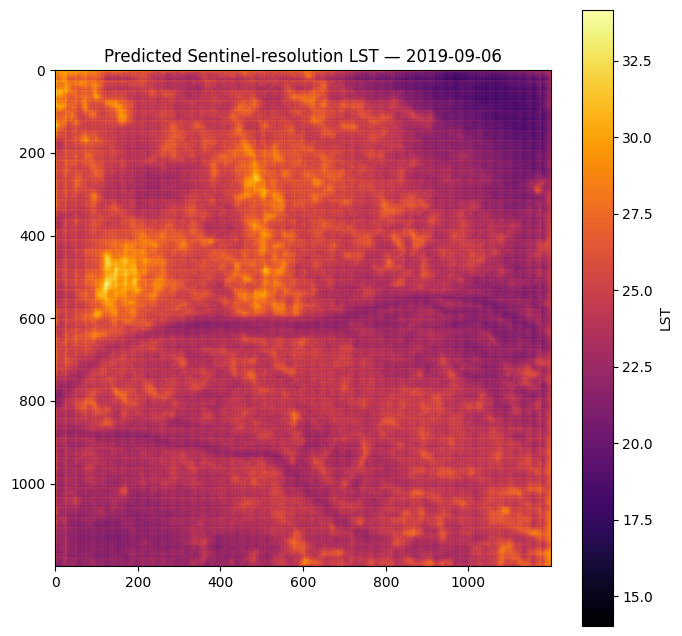

In [13]:
import rasterio 
import matplotlib.pyplot as plt 
import numpy as np

path = "data/Tdivision/test/01_Sentinel_20190906.tif"                                                                                                                     

with rasterio.open(path) as src:                                                                                                                                          
    arr = src.read()        # shape: (bands, H, W)
    print("shape:", arr.shape, "dtype:", arr.dtype)                                                                                                                       
    print("CRS:", src.crs, "  transform:", src.transform)
    print("min/mean/max:", np.nanmin(arr), np.nanmean(arr), np.nanmax(arr))                                                                                               
                                                                                                                                                                        
# Show band 1 (LST)                                                                                                                                                       
plt.figure(figsize=(8, 8))                                                                                                                                                
plt.imshow(arr[0], cmap="inferno")                                                                                                                                        
plt.colorbar(label="LST")                                                                                                                                                 
plt.title("Predicted Sentinel-resolution LST — 2019-09-06")
plt.show()  


In [15]:
from runner.evaluate import evaluate_predictions                                                                                                                                                        
                                                                                                                                                                                                    
df = evaluate_predictions(opt.test_dir)                                                                                                                                                                 
import pandas as pd
with pd.option_context("display.float_format", "{:.4f}".format):                                                                                                                                        
    print(df.to_string(index=False))                                                                                                                                                                  


 scene     date  n_pixels   RMSE    MAE    Bias  PSNR_dB  gt_min  gt_max  pred_min  pred_max
pair_0 20190906    160000 3.8639 3.1962 -1.4187  19.7990  3.9027 41.6581   17.5619   33.6317
   ALL             160000 3.8639 3.1962 -1.4187      NaN  3.9027 41.6581   17.5619   33.6317
